In [1]:
import pandas as pd
import numpy as np

# Cleaning
# Load data
path = "C:/Users/123li/Downloads/ECS/ECS171/project/heart_statlog_cleveland_hungary_final.csv"
df = pd.read_csv(path)
df

C:\Users\123li\AppData\Local\Temp\ipykernel_28656\3101664765.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1185,45,1,1,110,264,0,0,132,0,1.2,2,1
1186,68,1,4,144,193,1,0,141,0,3.4,2,1
1187,57,1,4,130,131,0,0,115,1,1.2,2,1
1188,57,0,2,130,236,0,2,174,0,0.0,2,1


In [2]:
print("Original shape:", df.shape)
print("Columns:", df.columns.tolist())

# Basic quality checks
print("\nMissing values per column:\n", df.isna().sum())
dup_count = df.duplicated().sum()
print("\nDuplicated rows:", dup_count)

# Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)
print("\nAfter dropping duplicates:", df.shape)

# Validate target
target_col = "target"
print("\nTarget value counts:\n", df[target_col].value_counts())
assert set(df[target_col].unique()).issubset({0, 1}), "Target is not binary {0,1}!"

# Handle implicit missing values
zero_as_missing_cols = ["cholesterol", "resting bp s", "ST slope"]

for c in zero_as_missing_cols:
    if c in df.columns:
        zero_count = (df[c] == 0).sum()
        print(f"\n{c}: zero count before = {zero_count}")
        df.loc[df[c] == 0, c] = np.nan

print("\nMissing values after converting zeros to NaN:\n", df.isna().sum())

# Imputation
# Decide which columns are continuous vs categorical
continuous_cols = ["age", "resting bp s", "cholesterol", "max heart rate", "oldpeak"]
categorical_cols = ["sex", "chest pain type", "fasting blood sugar",
                    "resting ecg", "exercise angina", "ST slope"]

# Median imputation for continuous
for c in continuous_cols:
    if c in df.columns:
        med = df[c].median()
        df[c] = df[c].fillna(med)

# Mode imputation for categorical/discrete
for c in categorical_cols:
    if c in df.columns:
        mode = df[c].mode(dropna=True)[0]
        df[c] = df[c].fillna(mode)

# Ensure categorical cols are int-coded
for c in categorical_cols + [target_col]:
    if c in df.columns:
        df[c] = df[c].astype(int)

print("\nFinal missing values per column:\n", df.isna().sum())
print("\nFinal shape:", df.shape)
print("\nData types:\n", df.dtypes)


# EDA
import os
import matplotlib.pyplot as plt

target_col = "target"

OUT_DIR = "eda_figures"
os.makedirs(OUT_DIR, exist_ok=True)

def save_fig(filename: str):
    path = os.path.join(OUT_DIR, filename)
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.close()
    print("Saved:", path)

# Target class distribution
counts = df[target_col].value_counts().sort_index()

plt.figure(figsize=(5, 4))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Target Class Distribution")
plt.xlabel("target (0=no disease, 1=disease)")
plt.ylabel("count")
save_fig("fig1_target_distribution.png")

# Continuous feature histograms
continuous_cols = ["age", "resting bp s", "cholesterol", "max heart rate", "oldpeak"]
continuous_cols = [c for c in continuous_cols if c in df.columns]

n = len(continuous_cols)
cols = 3
rows = int(np.ceil(n / cols))

plt.figure(figsize=(12, 4 * rows))
for i, c in enumerate(continuous_cols, 1):
    ax = plt.subplot(rows, cols, i)
    ax.hist(df[c], bins=30)
    ax.set_title(c)
    ax.set_xlabel(c)
    ax.set_ylabel("count")

plt.suptitle("Continuous Feature Distributions", y=1.02)
save_fig("fig2_continuous_histograms.png")

# oldpeak by target
feature = "oldpeak"
if feature in df.columns:
    data0 = df[df[target_col] == 0][feature]
    data1 = df[df[target_col] == 1][feature]

    plt.figure(figsize=(6, 4))
    plt.boxplot([data0, data1], labels=["target=0", "target=1"])
    plt.title("oldpeak by Target Class")
    plt.ylabel(feature)
    save_fig("fig3_oldpeak_by_target.png")
else:
    print("Warning: oldpeak not found, skip FIG 3")

# max heart rate by target (boxplot)
feature = "max heart rate"
if feature in df.columns:
    data0 = df[df[target_col] == 0][feature]
    data1 = df[df[target_col] == 1][feature]

    plt.figure(figsize=(6, 4))
    plt.boxplot([data0, data1], labels=["target=0", "target=1"])
    plt.title("max heart rate by Target Class")
    plt.ylabel(feature)
    save_fig("fig4_maxheartrate_by_target.png")

# Disease rate by exercise angina
cat = "exercise angina"
if cat in df.columns:
    rates = df.groupby(cat)[target_col].mean().sort_index()
    counts = df[cat].value_counts().sort_index()

    plt.figure(figsize=(6, 4))
    plt.bar(rates.index.astype(str), rates.values)
    plt.title("Disease Rate by Exercise Angina")
    plt.xlabel(cat + " (0=no, 1=yes)")
    plt.ylabel("P(target=1)")

    for i, (k, v) in enumerate(rates.items()):
        plt.text(i, v, f"n={counts.loc[k]}", ha="center", va="bottom", fontsize=9)

    save_fig("fig5_exerciseangina_disease_rate.png")

print("\nDone. Figures saved in:", OUT_DIR)

Original shape: (1190, 12)
Columns: ['age', 'sex', 'chest pain type', 'resting bp s', 'cholesterol', 'fasting blood sugar', 'resting ecg', 'max heart rate', 'exercise angina', 'oldpeak', 'ST slope', 'target']

Missing values per column:
 age                    0
sex                    0
chest pain type        0
resting bp s           0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
dtype: int64

Duplicated rows: 272

After dropping duplicates: (918, 12)

Target value counts:
 target
1    508
0    410
Name: count, dtype: int64

cholesterol: zero count before = 172

resting bp s: zero count before = 1

ST slope: zero count before = 1

Missing values after converting zeros to NaN:
 age                      0
sex                      0
chest pain type          0
resting bp s             1
cholesterol            172
fasting blood sugar     

In [3]:
# =============================================================================
# Feature Engineering
# =============================================================================

from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Save original data copy for feature creation
df_original = df.copy()

# -----------------------------------------------------------------------------
# 1. Feature Creation - Before scaling
# -----------------------------------------------------------------------------

# Age groups (based on heart disease risk age brackets)
df['age_group'] = pd.cut(df_original['age'], bins=[0, 40, 55, 70, 100], labels=[0, 1, 2, 3]).astype(int)

# Heart rate reserve (max predicted heart rate - actual max heart rate)
df['heart_rate_reserve'] = (220 - df_original['age']) - df_original['max heart rate']

# Cholesterol risk level (>200 is high risk)
df['chol_risk'] = (df_original['cholesterol'] > 200).astype(int)

# Blood pressure risk (>140 is hypertension)
df['bp_risk'] = (df_original['resting bp s'] > 140).astype(int)

# Oldpeak abnormal indicator
df['oldpeak_abnormal'] = (df_original['oldpeak'] > 0).astype(int)

print("New features created:")
print("- age_group: Age grouping (0=<40, 1=40-55, 2=55-70, 3=>70)")
print("- heart_rate_reserve: Heart rate reserve")
print("- chol_risk: Cholesterol risk (1=high)")
print("- bp_risk: Blood pressure risk (1=high)")
print("- oldpeak_abnormal: ST depression abnormal")

print("\nShape after feature creation:", df.shape)

New features created:
- age_group: Age grouping (0=<40, 1=40-55, 2=55-70, 3=>70)
- heart_rate_reserve: Heart rate reserve
- chol_risk: Cholesterol risk (1=high)
- bp_risk: Blood pressure risk (1=high)
- oldpeak_abnormal: ST depression abnormal

Shape after feature creation: (918, 17)


In [4]:
# -----------------------------------------------------------------------------
# 2. Categorical Variable One-Hot Encoding
# -----------------------------------------------------------------------------

# Columns to One-Hot encode (multi-class)
onehot_cols = ['chest pain type', 'ST slope', 'resting ecg']

print("Before One-Hot encoding:", df.shape)
print("Columns to encode:", onehot_cols)

for col in onehot_cols:
    print(f"  {col}: {df[col].unique()}")

# One-Hot encoding, drop_first=True to avoid multicollinearity
df = pd.get_dummies(df, columns=onehot_cols, drop_first=True)

print("\nAfter One-Hot encoding:", df.shape)
print("New columns:", [c for c in df.columns if any(oc in c for oc in onehot_cols)])

Before One-Hot encoding: (918, 17)
Columns to encode: ['chest pain type', 'ST slope', 'resting ecg']
  chest pain type: [2 3 4 1]
  ST slope: [1 2 3]
  resting ecg: [0 1 2]

After One-Hot encoding: (918, 21)
New columns: ['chest pain type_2', 'chest pain type_3', 'chest pain type_4', 'ST slope_2', 'ST slope_3', 'resting ecg_1', 'resting ecg_2']


In [5]:
# -----------------------------------------------------------------------------
# 3. Feature Scaling
# -----------------------------------------------------------------------------

# Continuous variables to scale
continuous_cols = ["age", "resting bp s", "cholesterol", "max heart rate", "oldpeak", "heart_rate_reserve"]

print("Scaling continuous features:", continuous_cols)
print("\nBefore scaling - statistics:")
print(df[continuous_cols].describe().round(2))

# Use StandardScaler (Z-score normalization)
scaler = StandardScaler()
df[continuous_cols] = scaler.fit_transform(df[continuous_cols])

print("\nAfter scaling - statistics:")
print(df[continuous_cols].describe().round(2))

Scaling continuous features: ['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak', 'heart_rate_reserve']

Before scaling - statistics:
          age  resting bp s  cholesterol  max heart rate  oldpeak  \
count  918.00        918.00        918.0          918.00   918.00   
mean    53.51        132.54        243.2          136.81     0.89   
std      9.43         17.99         53.4           25.46     1.07   
min     28.00         80.00         85.0           60.00    -2.60   
25%     47.00        120.00        214.0          120.00     0.00   
50%     54.00        130.00        237.0          138.00     0.60   
75%     60.00        140.00        267.0          156.00     1.50   
max     77.00        200.00        603.0          202.00     6.20   

       heart_rate_reserve  
count              918.00  
mean                29.68  
std                 23.53  
min                -29.00  
25%                 11.00  
50%                 29.00  
75%                 46.00  
max  

Feature correlation with target (sorted by |r|):

ST slope_2             0.554
chest pain type_4      0.517
exercise angina        0.494
oldpeak                0.404
chest pain type_2     -0.402
max heart rate        -0.400
oldpeak_abnormal       0.346
heart_rate_reserve     0.320
sex                    0.305
age                    0.282
fasting blood sugar    0.267
age_group              0.265
chest pain type_3     -0.213
bp_risk                0.145
chol_risk              0.142
ST slope_3             0.123
resting bp s           0.118
resting ecg_1          0.103
cholesterol            0.076
resting ecg_2          0.011
Name: target, dtype: float64


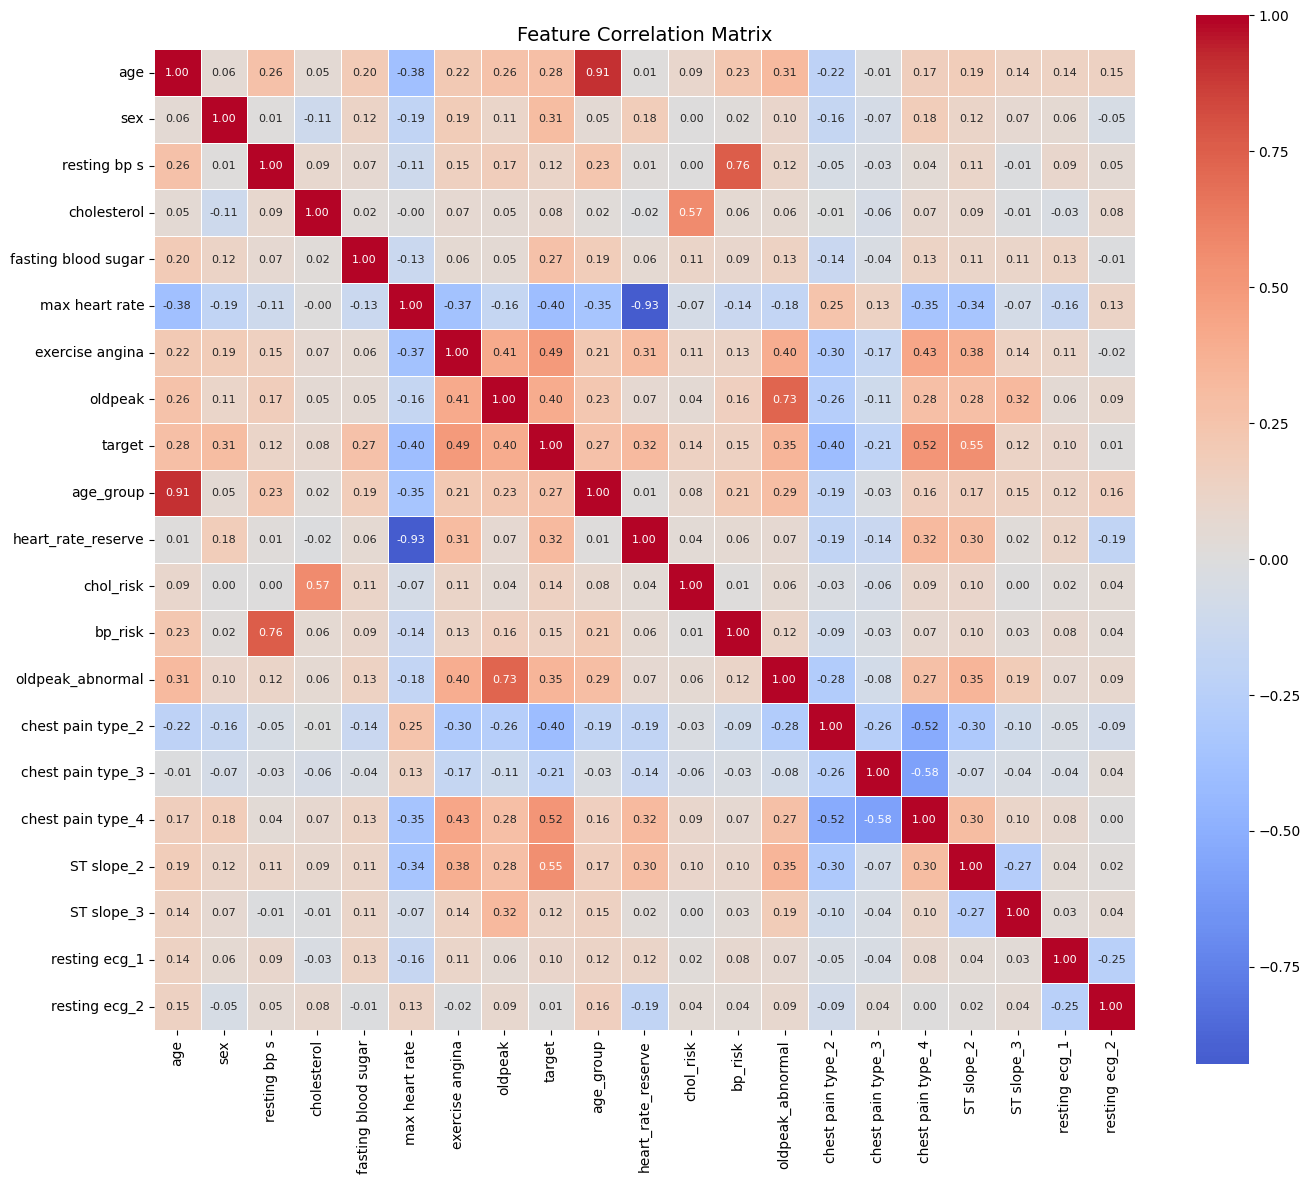


Saved: eda_figures/fig6_correlation_matrix.png


In [6]:
# -----------------------------------------------------------------------------
# 4. Correlation Analysis
# -----------------------------------------------------------------------------

# Compute correlation matrix
corr_matrix = df.corr()

# Correlation with target
target_corr = corr_matrix['target'].drop('target').sort_values(key=abs, ascending=False)
print("Feature correlation with target (sorted by |r|):\n")
print(target_corr.round(3))

# Plot correlation heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', 
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('eda_figures/fig6_correlation_matrix.png', dpi=200, bbox_inches='tight')
plt.show()
print("\nSaved: eda_figures/fig6_correlation_matrix.png")

Total features: 20
Feature names: ['age', 'sex', 'resting bp s', 'cholesterol', 'fasting blood sugar', 'max heart rate', 'exercise angina', 'oldpeak', 'age_group', 'heart_rate_reserve', 'chol_risk', 'bp_risk', 'oldpeak_abnormal', 'chest pain type_2', 'chest pain type_3', 'chest pain type_4', 'ST slope_2', 'ST slope_3', 'resting ecg_1', 'resting ecg_2']

Feature Importance (ANOVA F-test):

                feature   f_score  p_value
16           ST slope_2  405.9115   0.0000
15    chest pain type_4  333.6519   0.0000
6       exercise angina  296.1448   0.0000
7               oldpeak  178.6151   0.0000
13    chest pain type_2  176.4829   0.0000
5        max heart rate  174.9136   0.0000
12     oldpeak_abnormal  124.6887   0.0000
9    heart_rate_reserve  104.6418   0.0000
1                   sex   94.2532   0.0000
0                   age   79.1608   0.0000
4   fasting blood sugar   70.4785   0.0000
8             age_group   69.3483   0.0000
14    chest pain type_3   43.5175   0.0000
11    

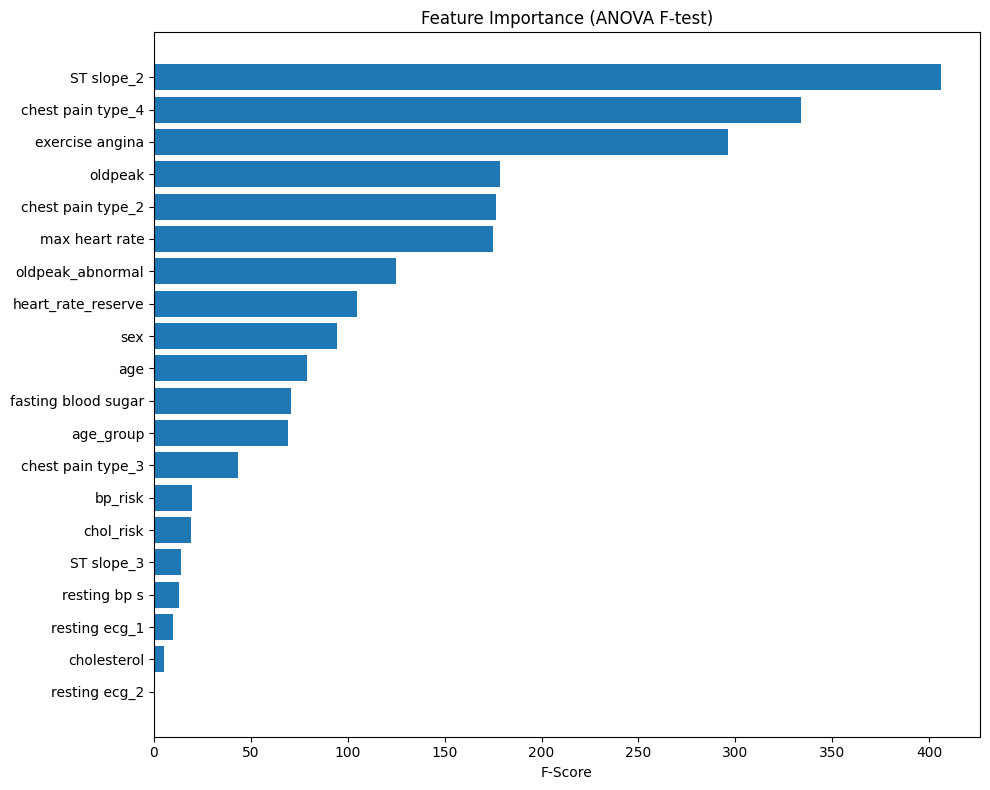


Saved: eda_figures/fig7_feature_importance.png


In [7]:
# -----------------------------------------------------------------------------
# 5. 特征选择 (Feature Selection)
# -----------------------------------------------------------------------------

from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

# 准备 X 和 y
X = df.drop('target', axis=1)
y = df['target']

print(f"Total features: {X.shape[1]}")
print(f"Feature names: {X.columns.tolist()}\n")

# 使用 ANOVA F-test 评估特征重要性
selector = SelectKBest(f_classif, k='all')
selector.fit(X, y)

# 特征得分排名
feature_scores = pd.DataFrame({
    'feature': X.columns,
    'f_score': selector.scores_,
    'p_value': selector.pvalues_
}).sort_values('f_score', ascending=False)

print("Feature Importance (ANOVA F-test):\n")
print(feature_scores.round(4))

# 可视化
plt.figure(figsize=(10, 8))
plt.barh(feature_scores['feature'], feature_scores['f_score'])
plt.xlabel('F-Score')
plt.title('Feature Importance (ANOVA F-test)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('eda_figures/fig7_feature_importance.png', dpi=200, bbox_inches='tight')
plt.show()
print("\nSaved: eda_figures/fig7_feature_importance.png")

In [8]:
# -----------------------------------------------------------------------------
# 6. Save Processed Data & Summary
# -----------------------------------------------------------------------------

# Select significant features (optional: based on p_value < 0.05)
significant_features = feature_scores[feature_scores['p_value'] < 0.05]['feature'].tolist()
print(f"Significant features (p < 0.05): {len(significant_features)}")
print(significant_features)

# Final dataset summary
print("\n" + "="*60)
print("FEATURE ENGINEERING SUMMARY")
print("="*60)
print(f"Original features: 11")
print(f"Final features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"\nTarget distribution:")
print(f"  - Class 0 (No disease): {(y == 0).sum()} ({(y == 0).mean()*100:.1f}%)")
print(f"  - Class 1 (Disease): {(y == 1).sum()} ({(y == 1).mean()*100:.1f}%)")

# Save processed data
output_path = "heart_disease_processed.csv"
df.to_csv(output_path, index=False)
print(f"\nProcessed data saved to: {output_path}")

# Display final dataset preview
print("\nFinal dataset preview:")
df.head()

Significant features (p < 0.05): 19
['ST slope_2', 'chest pain type_4', 'exercise angina', 'oldpeak', 'chest pain type_2', 'max heart rate', 'oldpeak_abnormal', 'heart_rate_reserve', 'sex', 'age', 'fasting blood sugar', 'age_group', 'chest pain type_3', 'bp_risk', 'chol_risk', 'ST slope_3', 'resting bp s', 'resting ecg_1', 'cholesterol']

FEATURE ENGINEERING SUMMARY
Original features: 11
Final features: 20
Samples: 918

Target distribution:
  - Class 0 (No disease): 410 (44.7%)
  - Class 1 (Disease): 508 (55.3%)

Processed data saved to: heart_disease_processed.csv

Final dataset preview:


,age,sex,resting bp s,cholesterol,fasting blood sugar,max heart rate,exercise angina,oldpeak,target,age_group,...,chol_risk,bp_risk,oldpeak_abnormal,chest pain type_2,chest pain type_3,chest pain type_4,ST slope_2,ST slope_3,resting ecg_1,resting ecg_2
0,-1.433140,1,0.415002,0.858035,0,1.382928,0,-0.832432,0,0,...,1,0,0,True,False,False,False,False,False,False
1,-0.478484,0,1.527329,-1.184227,0,0.754157,0,0.105664,1,1,...,0,1,1,False,True,False,True,False,False,False
2,-1.751359,1,-0.141161,0.745617,0,-1.525138,0,-0.832432,0,0,...,1,0,0,True,False,False,False,False,True,False
3,-0.584556,0,0.303769,-0.547191,0,-1.132156,1,0.574711,1,1,...,1,0,1,False,False,True,True,False,False,False
4,0.051881,1,0.971166,-0.903182,0,-0.581981,0,-0.832432,0,1,...,0,1,0,False,True,False,False,False,False,False


In [9]:

# Logistic Regression Baseline Model

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix


#load processed dataset
path='heart_disease_processed.csv'
df = pd.read_csv(path)
print('Dataset shape:', df.shape)
print(df.head())

#define
X=df.drop('target', axis=1)
y=df['target']

print('\nTotal feature:', X.shape[1])
print('Class distribution:\n', y.value_counts())

#split train-test

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

print('\nTrain size:', X_train.shape[0])
print("Test size:", X_test.shape[0])

#logistic regression with cross validation

logreg = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000)

param_grid={'C': [0.01,0.1,1,10,100]}

grid= GridSearchCV(logreg, param_grid, cv=5,scoring='accuracy')

grid.fit(X_train, y_train)
best_model=grid.best_estimator_
print('\nBest regularization parameter C:', grid.best_params_)

#evaluation

y_pred=best_model.predict(X_test)
y_prob=best_model.predict_proba(X_test)[:,1]

accuracy= accuracy_score(y_test,y_pred)
auc=roc_auc_score(y_test,y_prob)

print("\nLogistic Regression Results")
print('Test Accuracy:', round(accuracy,4))
print('Test AUC:', round(auc,4))

print('\nClassification Report:')
print(classification_report(y_test, y_pred))

print('\nConfusion Matrix:')
print(confusion_matrix(y_test,y_pred))

#Feature importance

coefficients=pd.Series(best_model.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)

print('\nTop Influenctial Features:')
print(coefficients.head(10))

Dataset shape: (918, 21)
        age  sex  resting bp s  cholesterol  fasting blood sugar  \
0 -1.433140    1      0.415002     0.858035                    0   
1 -0.478484    0      1.527329    -1.184227                    0   
2 -1.751359    1     -0.141161     0.745617                    0   
3 -0.584556    0      0.303769    -0.547191                    0   
4  0.051881    1      0.971166    -0.903182                    0   

   max heart rate  exercise angina   oldpeak  target  age_group  ...  \
0        1.382928                0 -0.832432       0          0  ...   
1        0.754157                0  0.105664       1          1  ...   
2       -1.525138                0 -0.832432       0          0  ...   
3       -1.132156                1  0.574711       1          1  ...   
4       -0.581981                0 -0.832432       0          1  ...   

   chol_risk  bp_risk  oldpeak_abnormal  chest pain type_2  chest pain type_3  \
0          1        0                 0             


Best regularization parameter C: {'C': 10}

Logistic Regression Results
Test Accuracy: 0.875
Test AUC: 0.9329

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86        82
           1       0.91      0.86      0.88       102

    accuracy                           0.88       184
   macro avg       0.87      0.88      0.87       184
weighted avg       0.88      0.88      0.88       184


Confusion Matrix:
[[73  9]
 [14 88]]

Top Influenctial Features:
ST slope_2             2.588489
chest pain type_4      1.418077
ST slope_3             1.364865
fasting blood sugar    1.353154
sex                    1.346922
oldpeak_abnormal      -1.156723
exercise angina        0.931411
bp_risk                0.918081
oldpeak                0.646619
chest pain type_3     -0.447236
dtype: float64


Initial decision tree accuracy score: 0.7663043478260869
The depth of the baseline tree is: 11


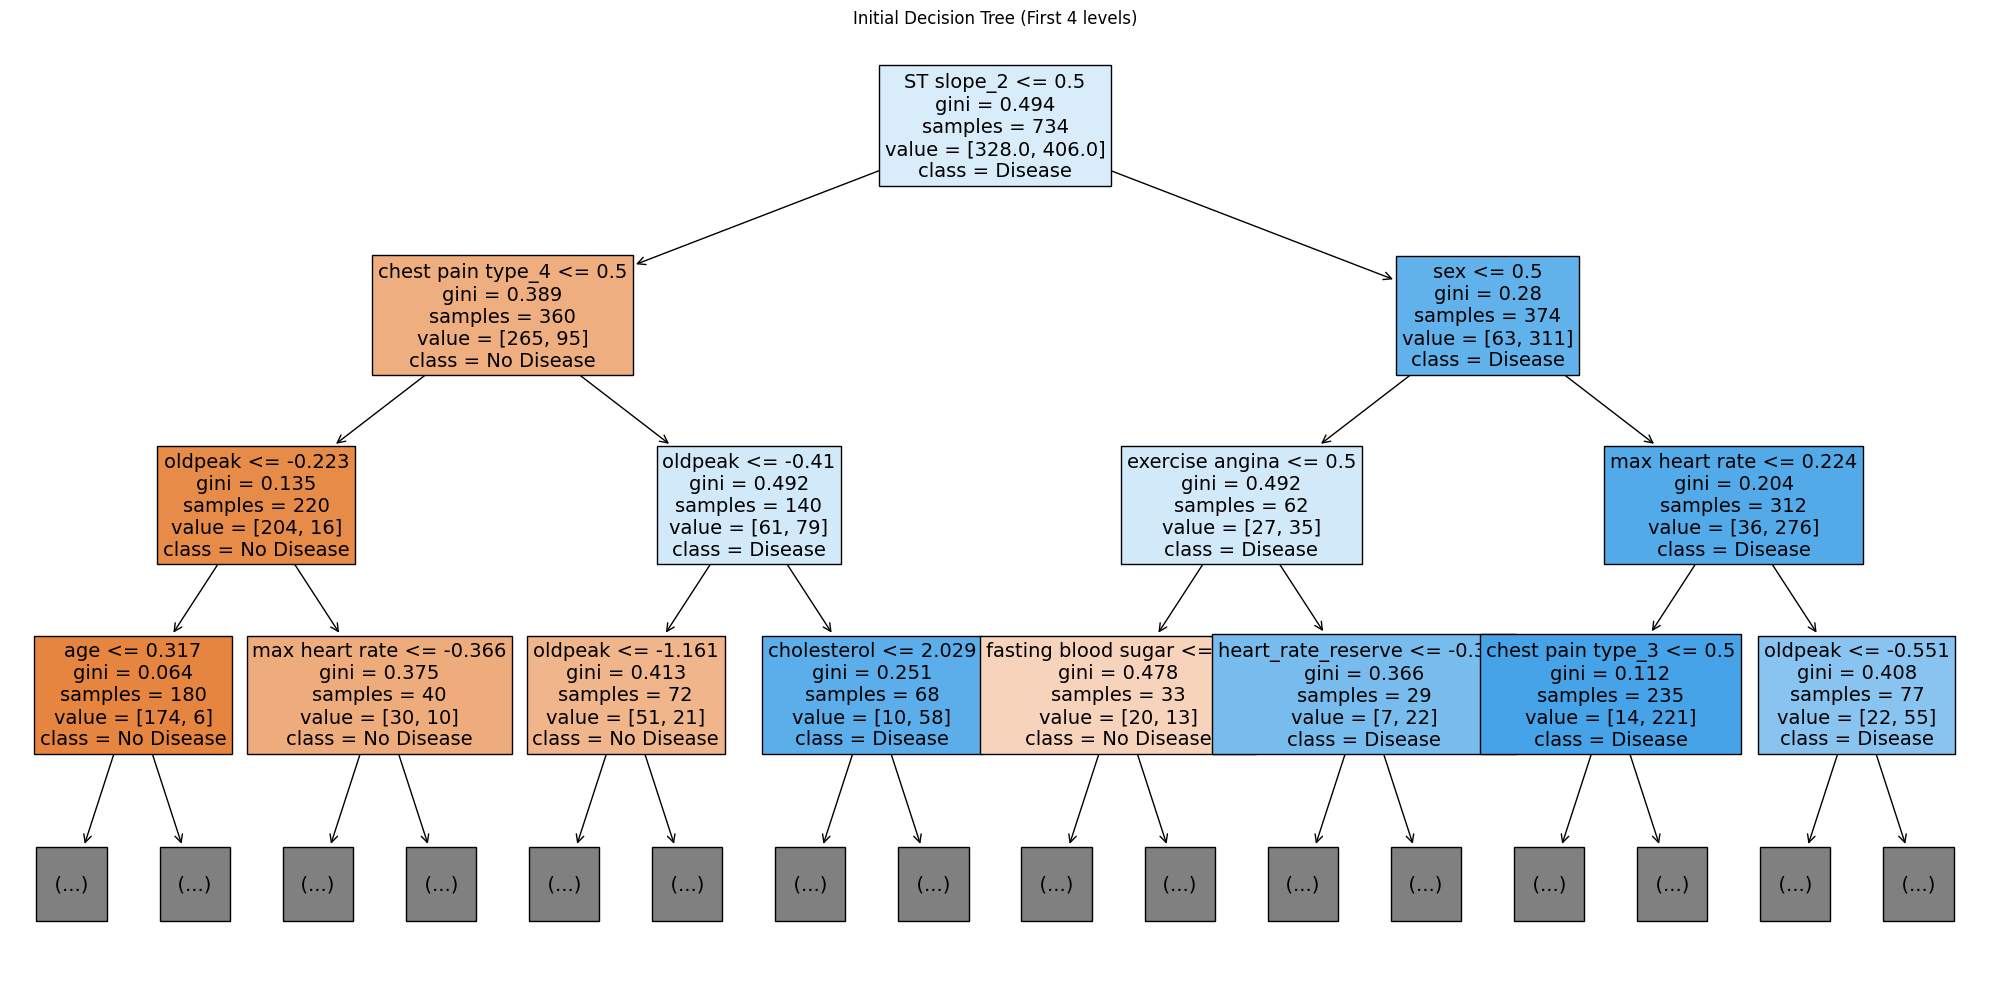


Saved: output_model2/fig_decision_tree_initial.png


In [ ]:
# Model 2: Decision Tree
from sklearn.tree import DecisionTreeClassifier, plot_tree

# preparing data: keep using the same train-test split from model 1

# Initialize the Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)

# Baseline model: fit the model
dt.fit(X_train, y_train)

# make an initial prediction on the test dataset
y_pred_dt = dt.predict(X_test)
print("Initial decision tree accuracy score:", accuracy_score(y_test, y_pred_dt))
print(f"The depth of the baseline tree is: {dt.get_depth()}")

# visualize the initial decision tree
plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=X.columns.tolist(), class_names=['No Disease', 'Disease'], max_depth = 3, fontsize = 14, filled=True)
plt.title("Initial Decision Tree (First 4 levels)")
plt.tight_layout()
plt.savefig('output_model2/fig_decision_tree_initial.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nSaved: output_model2/fig_decision_tree_initial.png")

In [48]:
# use grid search to perform hyper-parameter tuning based on max_depth, and min_samples_split
# max_depth: too deep can lead to overfitting, too shallow can lead to underfitting
# min_samples_split: the minimum number of samples required to split an internal node
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, roc_curve

param_grid = {
    'max_depth': [2, 3, 5, 7, 9, 10],
    'min_samples_split': [2, 4, 5, 10, 15],
    'criterion': ['gini', 'entropy']
}

# Initialize the GridSearchCV object
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), 
                           param_grid, 
                           cv=5, 
                           scoring='accuracy')
grid_search.fit(X_train, y_train)

# report the best params combination
best_comb = grid_search.best_params_
print("Best parameter combination:", best_comb)
# extract the best model
best_dt_model = grid_search.best_estimator_
print("Best cross-validation score:", grid_search.best_score_)

# use the best model to predict
y_pred = best_dt_model.predict(X_test)


Best parameter combination: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Best cross-validation score: 0.835103904575529


Decision Tree Model Evaluation Results:
Accuracy: 0.8370
AUC: 0.8887

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82        82
           1       0.87      0.83      0.85       102

    accuracy                           0.84       184
   macro avg       0.83      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184


Confusion Matrix:
[[69 13]
 [17 85]]


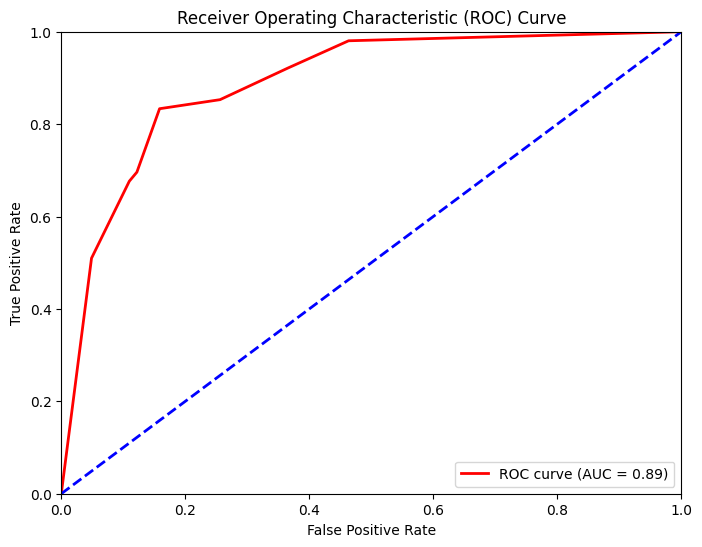

In [50]:
# evaluate the model
acc_score = accuracy_score(y_test, y_pred)

# get the probability of having disease to calculate AUC
y_pred_proba = best_dt_model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_pred_proba)

print("="*50)
print("Decision Tree Model Evaluation Results:")
print(f"Accuracy: {acc_score:.4f}")
print(f"AUC: {auc_score:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# plot the ROC curve
# false positive rate and true positive rate
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='red', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='blue', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.savefig('output_model2/roc_curve.png')
plt.show()

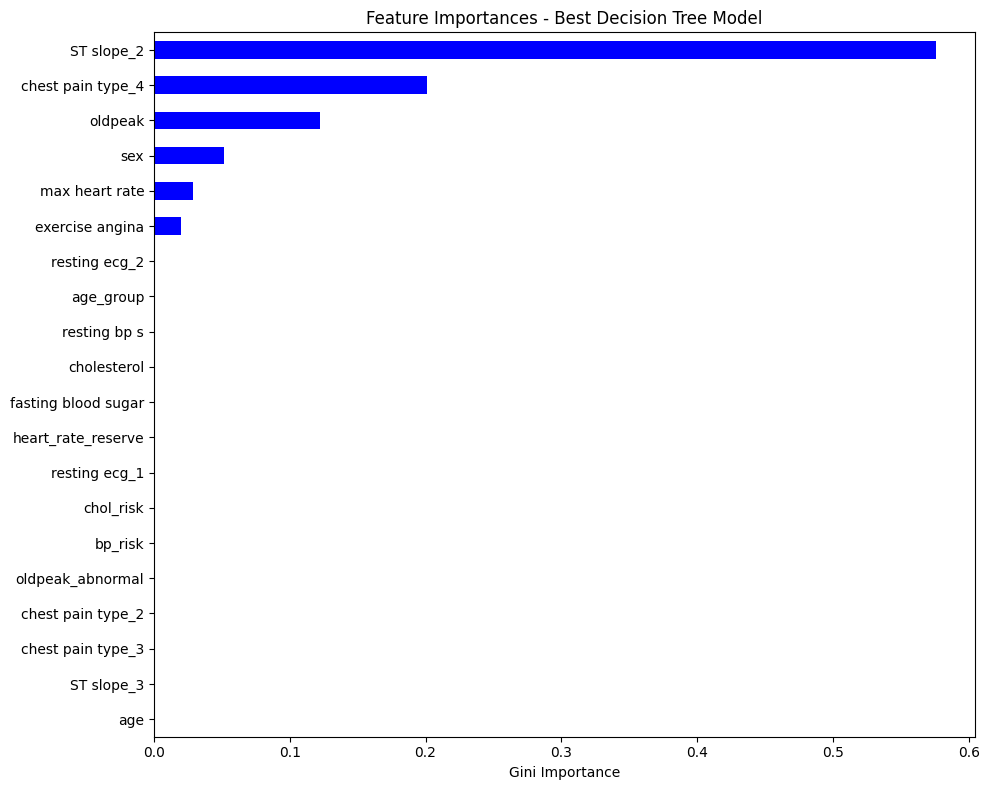

In [51]:
# visualize the feature importance
importances = best_dt_model.feature_importances_
feature_importances = pd.Series(importances, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
feature_importances.plot(kind='barh', color='blue')
plt.title('Feature Importances - Best Decision Tree Model')
plt.xlabel('Gini Importance')
plt.tight_layout()
plt.savefig('output_model2/fig_dt_feature_importance.png')
plt.show()

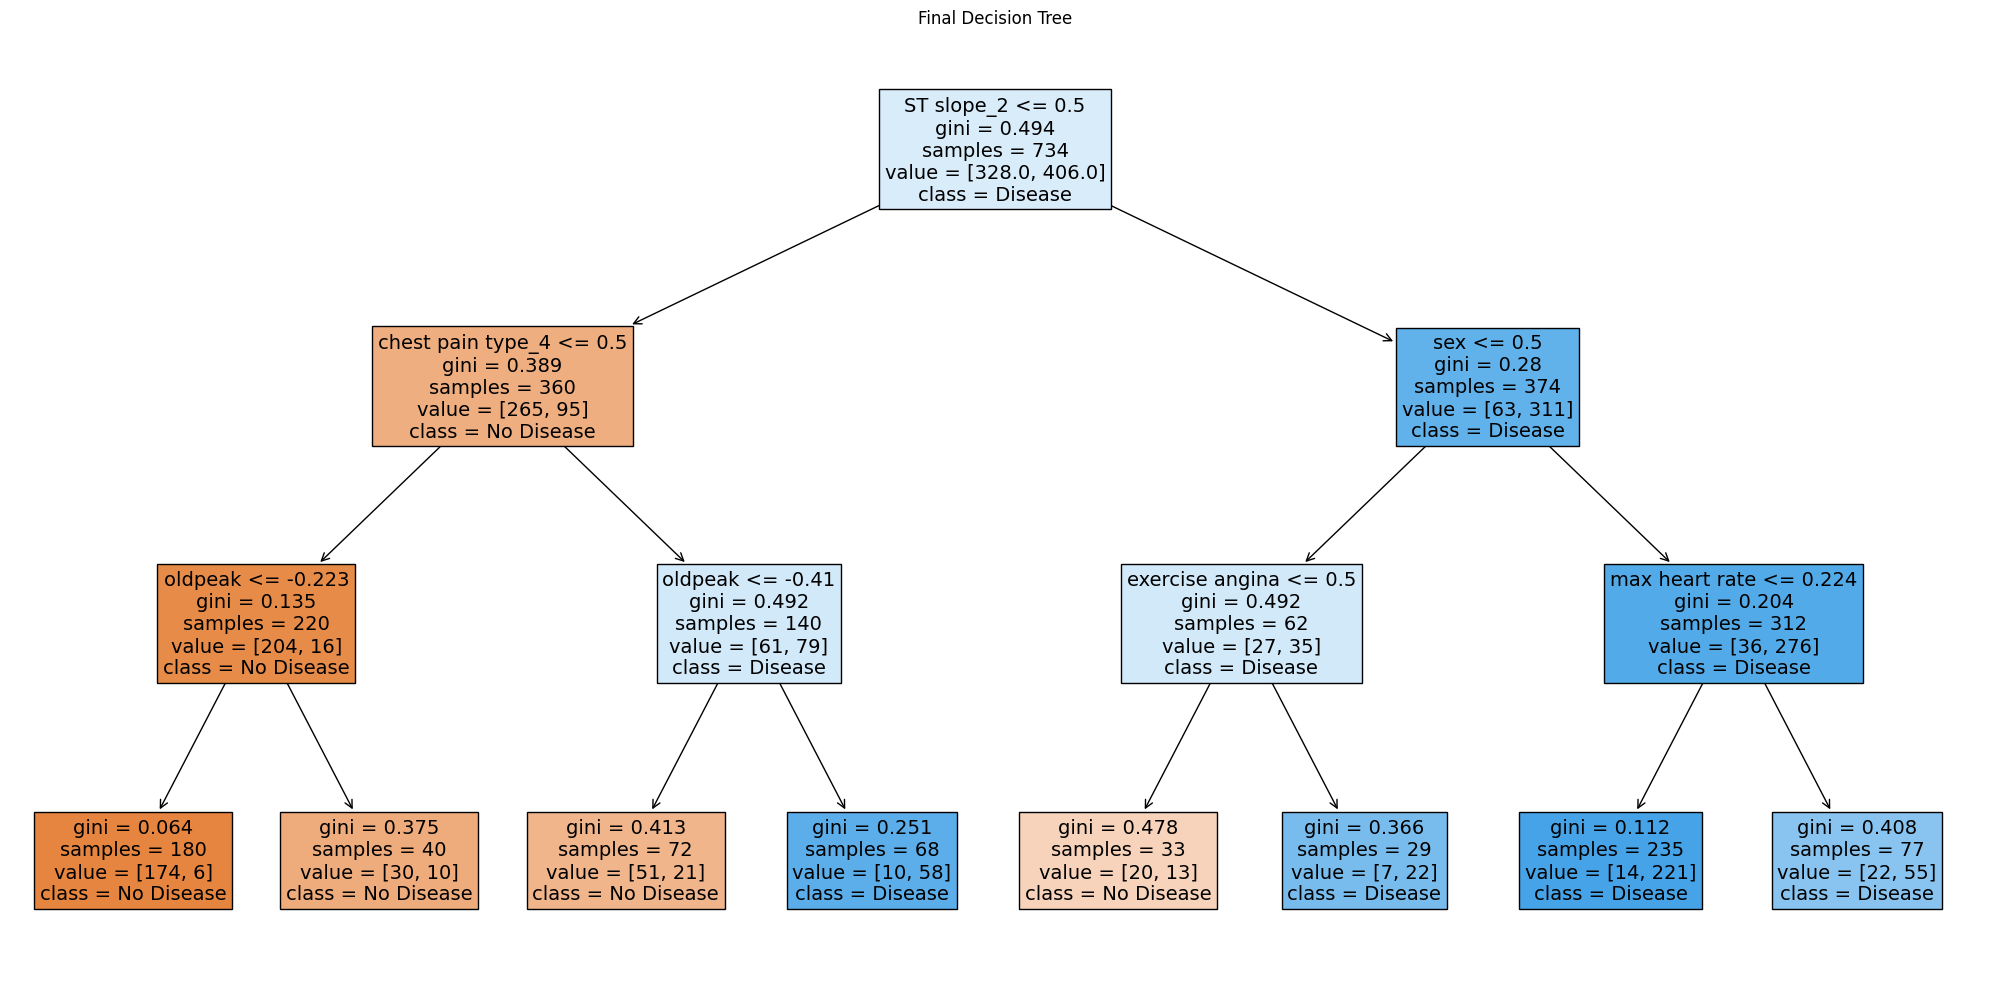

In [52]:
# visualize the best decision tree model
plt.figure(figsize=(20, 10))
plot_tree(best_dt_model, feature_names=X.columns.tolist(), class_names=['No Disease', 'Disease'], fontsize = 14, filled=True)
plt.title("Final Decision Tree")
plt.tight_layout()
plt.savefig('output_model2/fig_decision_tree_final.png', dpi=300, bbox_inches='tight')
plt.show()